## LPTEM simulator

This code is a modified version of Yao et al. https://github.com/chenlabUIUC/simulatedLPTEM in Python that generates simulated LPTEM videos for various sample thicknesses and various electron beam dose rates a microscope. The position and in plane orietation of the particles can be loaded from real LPTEM trajectories. 

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
from scipy.fft import fft2, ifft2, fftshift, ifftshift
import pandas as pd
import os


# Helper Functions

In [2]:
# Function to create an image with a nanorod at a specific position and orientation
def create_nanorod_image(image_size=(256, 256), position=(480, 128), rotation=360, width=30, height=60):
    """
    Generates a binary mask of a nanorod at a specific position and orientation.
    
    Parameters:
        image_size (tuple): Size of the output image.
        position (tuple): (x, y) position of the nanorod center.
        rotation (int): Rotation angle of the nanorod in degrees.
        width (int): Width of the nanorod.
        height (int): Height of the nanorod.
    
    Returns:
        np.ndarray: Binary mask of the nanorod.
    """
    image = np.zeros(image_size, dtype=np.uint8)
    center_x, center_y = position
    body = ((center_x, center_y), (height - width, width), rotation)
    box = cv2.boxPoints(body).astype(np.int32)
    cv2.drawContours(image, [box], 0, 255, -1)
    cap_radius = width // 2
    endpoint_vector = np.array([np.cos(np.deg2rad(rotation)), np.sin(np.deg2rad(rotation))]) * (height - width) / 2
    cap1_center = (int(center_x - endpoint_vector[0]), int(center_y - endpoint_vector[1]))
    cap2_center = (int(center_x + endpoint_vector[0]), int(center_y + endpoint_vector[1]))
    cv2.circle(image, cap1_center, cap_radius, 255, -1)
    cv2.circle(image, cap2_center, cap_radius, 255, -1)
    return image


In [3]:
# Function to simulate a single TEM image
def simulate_tem_image(mask, detectorRES=512, detectorScale=2, beamFlux=30, IMFPgold=20+50, IMFPwater=185, 
                        IMFPSiNx=144, thicknessWater=150, thicknessCell=50, conversionFactor=37.46):
    """
    Simulates a TEM image given a particle mask.
    
    Parameters:
        mask (np.ndarray): Binary mask of the particle.
    
    Returns:
        np.ndarray: Simulated TEM image.
    """ 
    image_size = detectorRES #i.e., 512 by 512 images
    holderFactor = 1  # guess
    exposureTime = 1  # seconds
    PARTICLERES = 512  # not sure what this is
    
    #white image with nanoparticle mask
    sim = np.zeros((image_size, image_size))
    mask = mask==255
    sim[mask] = 4.5 
    
    water = np.ones((image_size, image_size)) * thicknessWater
    cell = np.ones((image_size, image_size)) * 2*thicknessCell
    
    # background stuff
    sim *= detectorScale  # Convert to nm/pixel scale
    water -= sim  # Adjust water layer to account for nanoparticle
        
    sim0 = beamFlux * holderFactor * np.exp(-(sim / IMFPgold + water / IMFPwater + cell / IMFPSiNx))
   
    # noise + transforms
    sim = np.random.poisson(sim0)
    sim = np.random.normal(sim, 1)
   
    
    FT = fft2(sim)
    FT = fftshift(FT)  # Shift zero frequency to center
    
    
    MTFmatrix = loadmat(f'MTFmatrix512.mat')['MTFmatrix'] 
    FT = FT * MTFmatrix  # Apply MTF filter
    FT = ifftshift(FT)  # Inverse shift
    sim = np.abs(ifft2(FT))  # Inverse FFT to get the simulated image
    sim *= conversionFactor  
   
    return sim


# Load LPTEM trajectory to extract x and y coordinates

In [4]:
# Load the Excel file and specify the sheet name
file_path = "SAM4EM_lptem_trajectory.xlsx"
sheet_name = "20240410_AuNR14_dose35"

# Read the sheet into a DataFrame
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Extract x, y coordinates and angles
positions = df[["x", "y"]].to_numpy()  # Convert x and y to a numpy array of positions
angles = df["Angle"].to_numpy()       # Convert the Angle column to a numpy array

# Print the extracted arrays for verification
print("Positions:\n", positions.shape)
print("Angles:\n", angles.shape)

Positions:
 (2937, 2)
Angles:
 (2937,)


# Simulate LPTEM video with 150nm water thickness

### Simulated images and masks

In [5]:
os.makedirs("simulated_images_layer150nm", exist_ok=True)
os.makedirs("simulated_masks_layer150nm", exist_ok=True)

image_size = (512, 512)
simulated_images_layer150nm = []
simulated_masks_layer150nm = []

for idx, position in enumerate(positions):
    rotation = float(angles[idx])  # Explicitly cast to float
    
    # Generate the nanorod mask for the current position and rotation
    mask = create_nanorod_image(image_size=image_size, position=tuple(position), rotation=rotation)
    
    # Simulate the TEM image
    simulated_image = simulate_tem_image(mask=mask, thicknessWater=150)
    simulated_images_layer150nm.append(simulated_image)
    simulated_masks_layer150nm.append(mask)

    # Save the simulated image and mask as PNG
    simulated_image_path = f"simulated_images_layer150nm/simulated_image_{idx + 1:03d}.png"
    mask_path = f"simulated_masks_layer150nm/mask_{idx + 1:03d}.png"

    # Normalize and save the simulated image
    normalized_image = cv2.normalize(simulated_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    cv2.imwrite(simulated_image_path, normalized_image)

    # Save the mask as an 8-bit PNG
    cv2.imwrite(mask_path, mask)


print("Simulated images and masks have been saved.")

Simulated images and masks have been saved.


### Video file

In [6]:
# Parameters for the video
output_file = "simulated_video_layer150nm.avi"  # Output file name
frame_rate = 80  # Frames per second
frame_size = simulated_images_layer150nm[0].shape[::-1]  # (width, height), OpenCV expects (W, H)

# Define the codec and create a VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec for AVI format
out = cv2.VideoWriter(output_file, fourcc, frame_rate, frame_size, isColor=False)

# Write each frame to the video
for frame in simulated_images_layer150nm:
    # Convert the frame to uint8 format and scale to 0-255 if needed
    frame_uint8 = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Write the frame to the video
    out.write(frame_uint8)

# Release the video writer
out.release()

print(f"Video saved as {output_file}")


Video saved as simulated_video_layer150nm.avi


### Signal to Noise ratio values

Average SNR across all frames: 0.42


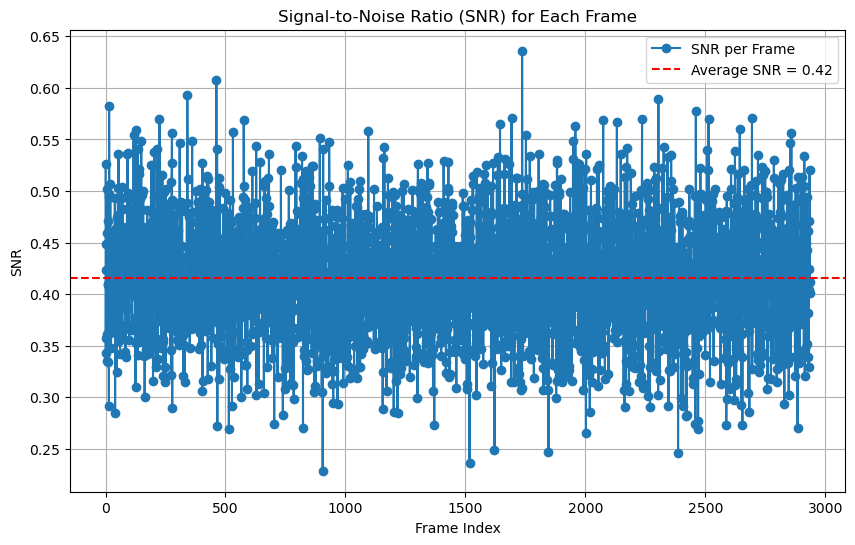

In [7]:
snr_values = []

for simulated_image, mask in zip(simulated_images_layer150nm, simulated_masks_layer150nm):
    # Convert mask to binary
    binary_mask = mask > 0

    # Extract signal (particle) and background regions
    signal_region = simulated_image[binary_mask]  # Darker (lower intensity) region
    background_region = simulated_image[~binary_mask]  # Brighter (higher intensity) region

    # Compute mean and standard deviation
    mean_signal = np.mean(signal_region)
    mean_background = np.mean(background_region)
    std_background = np.std(background_region)

    # Compute SNR (accounting for darker signal region)
    snr = (mean_background - mean_signal) / std_background if std_background > 0 else np.inf
    snr_values.append(snr)

# Calculate overall statistics
average_snr = np.mean(snr_values)
print(f"Average SNR across all frames: {average_snr:.2f}")

# Plot SNR values
plt.figure(figsize=(10, 6))
plt.plot(snr_values, marker='o', label='SNR per Frame')
plt.axhline(average_snr, color='r', linestyle='--', label=f'Average SNR = {average_snr:.2f}')
plt.xlabel("Frame Index")
plt.ylabel("SNR")
plt.title("Signal-to-Noise Ratio (SNR) for Each Frame")
plt.legend()
plt.grid()
plt.show()

In [8]:
# Save SNR values as a .npy file
output_file = "snr_values_150.npy"
np.save(output_file, snr_values)

print(f"SNR values saved as {output_file}")

SNR values saved as snr_values_150.npy


# Simulate LPTEM video with 50nm water thickness

### Simulated images and masks

In [9]:
os.makedirs("simulated_images_layer50nm", exist_ok=True)
os.makedirs("simulated_masks_layer50nm", exist_ok=True)

image_size = (512, 512)
simulated_images_layer50nm = []
simulated_masks_layer50nm = []

for idx, position in enumerate(positions):
    rotation = float(angles[idx])  # Explicitly cast to float
    
    # Generate the nanorod mask for the current position and rotation
    mask = create_nanorod_image(image_size=image_size, position=tuple(position), rotation=rotation)
    
    # Simulate the TEM image
    simulated_image = simulate_tem_image(mask=mask, thicknessWater=50)
    simulated_images_layer50nm.append(simulated_image)
    simulated_masks_layer50nm.append(mask)

    # Save the simulated image and mask as PNG
    simulated_image_path = f"simulated_images_layer50nm/simulated_image_{idx + 1:03d}.png"
    mask_path = f"simulated_masks_layer50nm/mask_{idx + 1:03d}.png"

    # Normalize and save the simulated image
    normalized_image = cv2.normalize(simulated_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    cv2.imwrite(simulated_image_path, normalized_image)

    # Save the mask as an 8-bit PNG
    cv2.imwrite(mask_path, mask)


print("Simulated images and masks have been saved.")


Simulated images and masks have been saved.


### Video file

In [10]:
# Parameters for the video
output_file = "simulated_video_layer50nm.avi"  # Output file name
frame_rate = 80  # Frames per second
frame_size = simulated_images_layer50nm[0].shape[::-1]  # (width, height), OpenCV expects (W, H)

# Define the codec and create a VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec for AVI format
out = cv2.VideoWriter(output_file, fourcc, frame_rate, frame_size, isColor=False)

# Write each frame to the video
for frame in simulated_images_layer50nm:
    # Convert the frame to uint8 format and scale to 0-255 if needed
    frame_uint8 = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Write the frame to the video
    out.write(frame_uint8)

# Release the video writer
out.release()

print(f"Video saved as {output_file}")


Video saved as simulated_video_layer50nm.avi


### Signal to Noise ratio values

Average SNR across all frames: 0.56


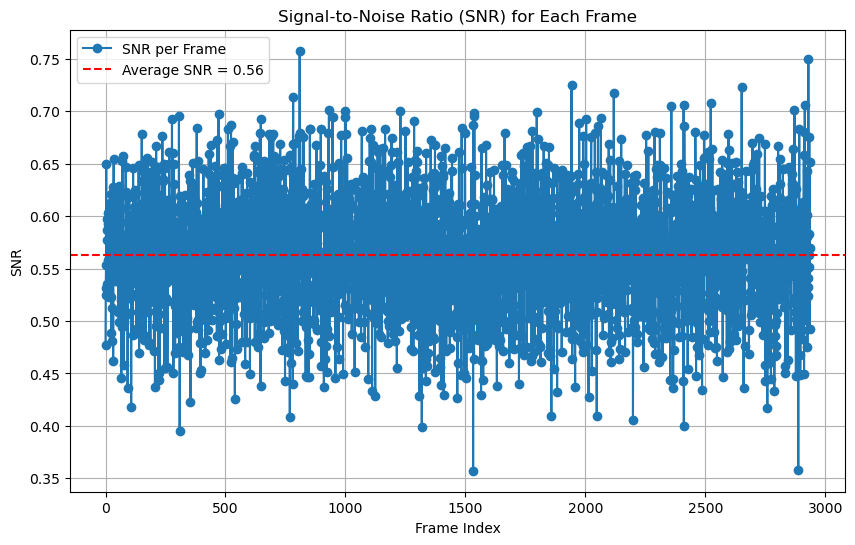

In [11]:
snr_values = []

for simulated_image, mask in zip(simulated_images_layer50nm, simulated_masks_layer50nm):
    # Convert mask to binary
    binary_mask = mask > 0

    # Extract signal (particle) and background regions
    signal_region = simulated_image[binary_mask]  # Darker (lower intensity) region
    background_region = simulated_image[~binary_mask]  # Brighter (higher intensity) region

    # Compute mean and standard deviation
    mean_signal = np.mean(signal_region)
    mean_background = np.mean(background_region)
    std_background = np.std(background_region)

    # Compute SNR (accounting for darker signal region)
    snr = (mean_background - mean_signal) / std_background if std_background > 0 else np.inf
    snr_values.append(snr)

# Calculate overall statistics
average_snr = np.mean(snr_values)
print(f"Average SNR across all frames: {average_snr:.2f}")

# Plot SNR values
plt.figure(figsize=(10, 6))
plt.plot(snr_values, marker='o', label='SNR per Frame')
plt.axhline(average_snr, color='r', linestyle='--', label=f'Average SNR = {average_snr:.2f}')
plt.xlabel("Frame Index")
plt.ylabel("SNR")
plt.title("Signal-to-Noise Ratio (SNR) for Each Frame")
plt.legend()
plt.grid()
plt.show()

In [12]:
# Save SNR values as a .npy file
output_file = "snr_values_50.npy"
np.save(output_file, snr_values)

print(f"SNR values saved as {output_file}")

SNR values saved as snr_values_50.npy


# Simulate LPTEM video with 5nm water thickness

### Simulated images and masks

In [ ]:
os.makedirs("simulated_images_layer5nm", exist_ok=True)
os.makedirs("simulated_masks_layer5nm", exist_ok=True)

image_size = (512, 512)
simulated_images_layer5nm = []
simulated_masks_layer5nm = []

for idx, position in enumerate(positions):
    rotation = float(angles[idx])  # Explicitly cast to float
    
    # Generate the nanorod mask for the current position and rotation
    mask = create_nanorod_image(image_size=image_size, position=tuple(position), rotation=rotation)
    
    # Simulate the TEM image
    simulated_image = simulate_tem_image(mask=mask, thicknessWater=5)
    simulated_images_layer5nm.append(simulated_image)
    simulated_masks_layer5nm.append(mask)

    # Save the simulated image and mask as PNG
    simulated_image_path = f"simulated_images_layer5nm/simulated_image_{idx + 1:03d}.png"
    mask_path = f"simulated_masks_layer5nm/mask_{idx + 1:03d}.png"

    # Normalize and save the simulated image
    normalized_image = cv2.normalize(simulated_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    cv2.imwrite(simulated_image_path, normalized_image)

    # Save the mask as an 8-bit PNG
    cv2.imwrite(mask_path, mask)

print("Simulated images and masks have been saved.")


### Video file

In [20]:
# Parameters for the video
output_file = "simulated_video_layer5nm.avi"  # Output file name
frame_rate = 80  # Frames per second
frame_size = simulated_images_layer5nm[0].shape[::-1]  # (width, height), OpenCV expects (W, H)

# Define the codec and create a VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # Codec for AVI format
out = cv2.VideoWriter(output_file, fourcc, frame_rate, frame_size, isColor=False)

# Write each frame to the video
for frame in simulated_images_layer5nm:
    # Convert the frame to uint8 format and scale to 0-255 if needed
    frame_uint8 = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Write the frame to the video
    out.write(frame_uint8)

# Release the video writer
out.release()

print(f"Video saved as {output_file}")

Video saved as simulated_video_layer5nm.avi


### Signal to Noise ratio values

Average SNR across all frames: 0.64


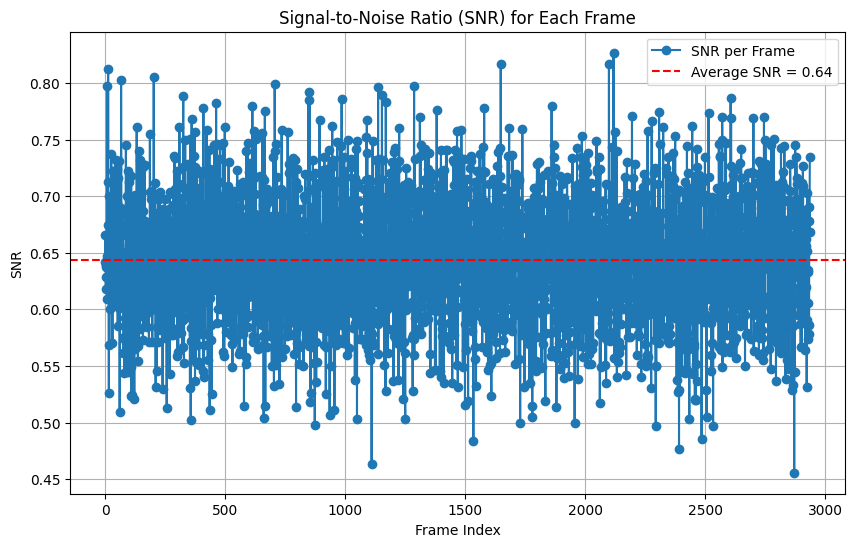

In [21]:
snr_values = []

for simulated_image, mask in zip(simulated_images_layer5nm, simulated_masks_layer5nm):
    # Convert mask to binary
    binary_mask = mask > 0

    # Extract signal (particle) and background regions
    signal_region = simulated_image[binary_mask]  # Darker (lower intensity) region
    background_region = simulated_image[~binary_mask]  # Brighter (higher intensity) region

    # Compute mean and standard deviation
    mean_signal = np.mean(signal_region)
    mean_background = np.mean(background_region)
    std_background = np.std(background_region)

    # Compute SNR (accounting for darker signal region)
    snr = (mean_background - mean_signal) / std_background if std_background > 0 else np.inf
    snr_values.append(snr)

# Calculate overall statistics
average_snr = np.mean(snr_values)
print(f"Average SNR across all frames: {average_snr:.2f}")

# Plot SNR values
plt.figure(figsize=(10, 6))
plt.plot(snr_values, marker='o', label='SNR per Frame')
plt.axhline(average_snr, color='r', linestyle='--', label=f'Average SNR = {average_snr:.2f}')
plt.xlabel("Frame Index")
plt.ylabel("SNR")
plt.title("Signal-to-Noise Ratio (SNR) for Each Frame")
plt.legend()
plt.grid()
plt.show()

In [22]:
# Save SNR values as a .npy file
output_file = "snr_values_5.npy"
np.save(output_file, snr_values)

print(f"SNR values saved as {output_file}")

SNR values saved as snr_values_5.npy
